<a href="https://colab.research.google.com/github/TRBatkin/Machine-Learning/blob/main/ML_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/strikersps/Brain-MRI-Image-Classification-Using-Deep-Learning.git
%cd Brain-MRI-Image-Classification-Using-Deep-Learning


Cloning into 'Brain-MRI-Image-Classification-Using-Deep-Learning'...
remote: Enumerating objects: 9831, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 9831 (delta 73), reused 15 (delta 5), pack-reused 9712 (from 1)
Receiving objects: 100% (9831/9831), 1.87 GiB | 27.17 MiB/s, done.
Resolving deltas: 100% (3212/3212), done.
Updating files: 100% (9611/9611), done.
Filtering content: 100% (2/2), 151.83 MiB | 56.43 MiB/s, done.
/content/Brain-MRI-Image-Classification-Using-Deep-Learning


In [ ]:
!pip install tensorflow numpy matplotlib scikit-learn opencv-python


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


77/77 ━━━━━━━━━━━━━━━━━━━━ 67s 851ms/step - accuracy: 0.5663 - loss: 0.9123 - val_accuracy: 0.6835 - val_loss: 0.7473
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 65s 845ms/step - accuracy: 0.6946 - loss: 0.7251 - val_accuracy: 0.6998 - val_loss: 0.7150
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 64s 831ms/step - accuracy: 0.7064 - loss: 0.6709 - val_accuracy: 0.6966 - val_loss: 0.6843
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 67s 874ms/step - accuracy: 0.7106 - loss: 0.6484 - val_accuracy: 0.7047 - val_loss: 0.6854
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 65s 839ms/step - accuracy: 0.7171 - loss: 0.6439 - val_accuracy: 0.6949 - val_loss: 0.6639
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 65s 845ms/step - accuracy: 0.7047 - loss: 0.6508 - val_accuracy: 0.7047 - val_loss: 0.6708
Epoch 7/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 64s 835ms/step - accuracy: 0.7295 - loss: 0.6322 - val_accuracy: 0.7194 - val_loss: 0.6309
Epoch 8/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 63s 816ms/step - accuracy: 0.7361 - loss: 0.6199 - val_accuracy: 0.717

Test Accuracy: 75.04%


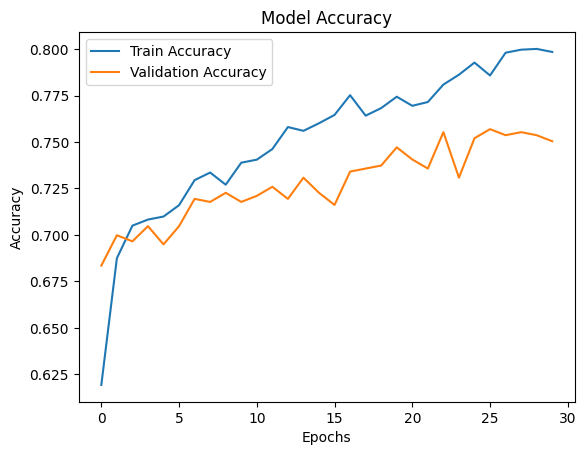

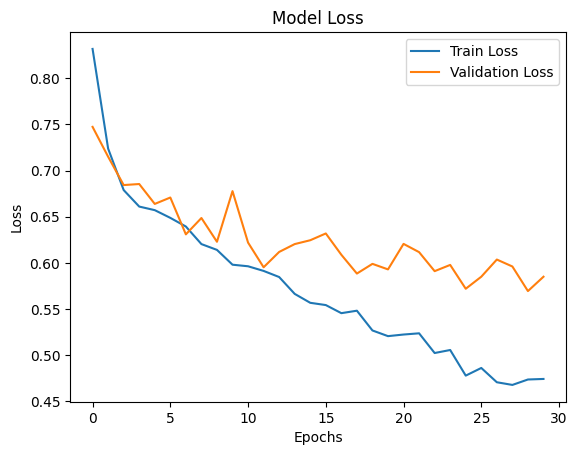

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Set Dataset Path
DATASET_PATH = './Brain-Tumor-Dataset/Tumor-Mask'

# Load Images and Labels
def load_images(data_path):
    images = []
    labels = []
    label_map = {'glioma': 0, 'pituitary_tumor': 1, 'meningioma': 2}

    for label_name, label in label_map.items():
        path = os.path.join(data_path, label_name)
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (128, 128))
                images.append(img)
                labels.append(label)

    return np.array(images), np.array(labels)

# Load and preprocess data
X, y = load_images(DATASET_PATH)
X = X.reshape(-1, 128, 128, 1) / 255.0
y = to_categorical(y, num_classes=3)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Augmentation
datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1, horizontal_flip=True)
datagen.fit(X_train)

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=30, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Save the model
model.save('brain_tumor_model.h5')

# Plot accuracy and loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
import os

# Set Dataset Path
DATASET_PATH = './Brain-Tumor-Dataset/Tumor-Mask'

# Define the tumor categories (include 'no_tumor' if available)
label_map = {'glioma': 0, 'pituitary_tumor': 1, 'meningioma': 2, 'no_tumor': 3}

# List example images for each category
def list_example_images(data_path, examples_per_category=5):
    for label_name in label_map.keys():
        path = os.path.join(data_path, label_name)
        if os.path.exists(path):
            images = os.listdir(path)[:examples_per_category]
            print(f"\nExample images for '{label_name}':")
            for img in images:
                print(f"- {img}")
        else:
            print(f"\nNo images found for '{label_name}' or directory does not exist.")

# Run the function
list_example_images(DATASET_PATH)



Example images for 'glioma':
- G1159.jpg
- G1236.jpg
- G820.jpg
- G134.jpg
- G1172.jpg

Example images for 'pituitary_tumor':
- P527.jpg
- P53.jpg
- P303.jpg
- P288.jpg
- P225.jpg

Example images for 'meningioma':
- M394.jpg
- M61.jpg
- M170.jpg
- M446.jpg
- M11.jpg

No images found for 'no_tumor' or directory does not exist.



Example images for 'glioma':


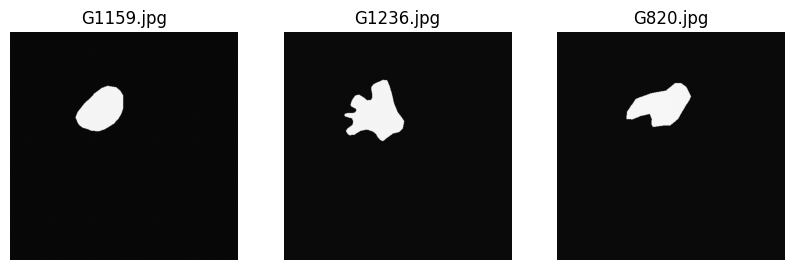


Example images for 'pituitary_tumor':


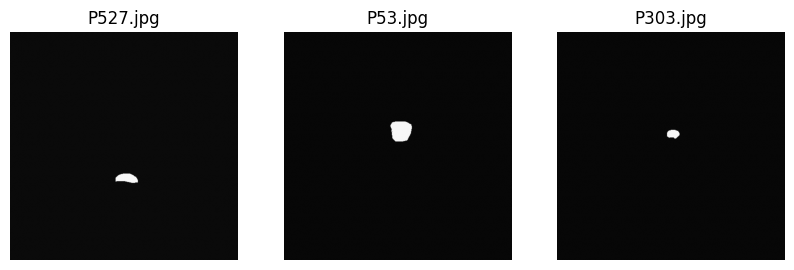


Example images for 'meningioma':


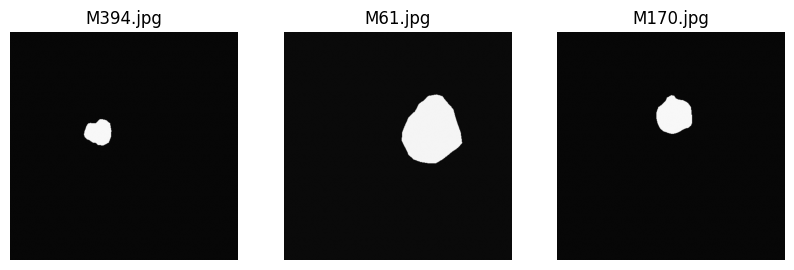


No images found for 'no_tumor' or directory does not exist.


In [ ]:
# prompt: I want to display the images found above, and their original images

import matplotlib.pyplot as plt
import cv2
import os

# Set Dataset Path
DATASET_PATH = './Brain-Tumor-Dataset/Tumor-Mask'

# Define the tumor categories
label_map = {'glioma': 0, 'pituitary_tumor': 1, 'meningioma': 2, 'no_tumor': 3}

# Function to display example images
def display_example_images(data_path, examples_per_category=3):
    for label_name in label_map.keys():
        path = os.path.join(data_path, label_name)
        if os.path.exists(path):
            images = os.listdir(path)[:examples_per_category]
            print(f"\nExample images for '{label_name}':")
            plt.figure(figsize=(10, 5))
            for i, img_name in enumerate(images):
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    plt.subplot(1, examples_per_category, i + 1)
                    plt.imshow(img, cmap='gray')
                    plt.title(img_name)
                    plt.axis('off')
            plt.show()
        else:
            print(f"\nNo images found for '{label_name}' or directory does not exist.")

# Display example images
display_example_images(DATASET_PATH)


Saving 1.jpg to 1.jpg
Saving 2.jpg to 2.jpg
Saving 3.jpg to 3.jpg
Saving 4.jpg to 4.jpg
Saving 5.jpg to 5.jpg
Saving 6.jpg to 6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


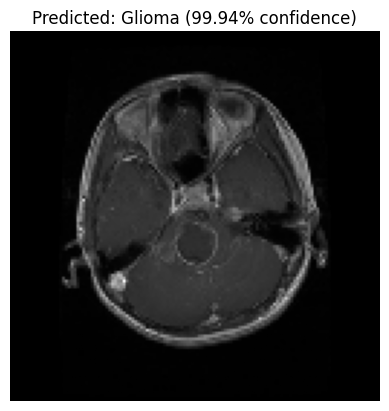

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


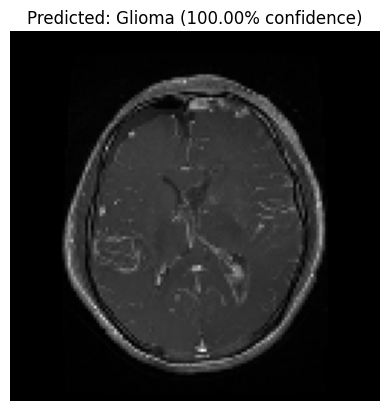

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


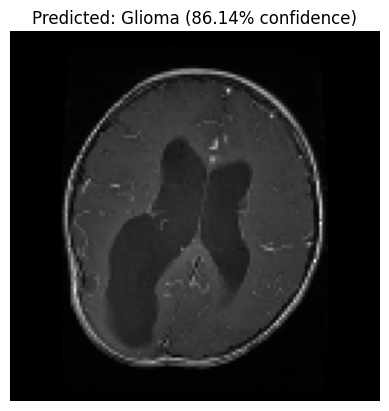

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


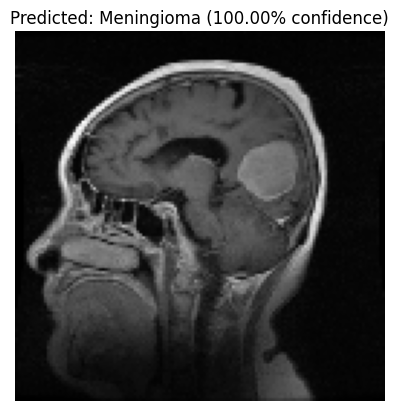

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


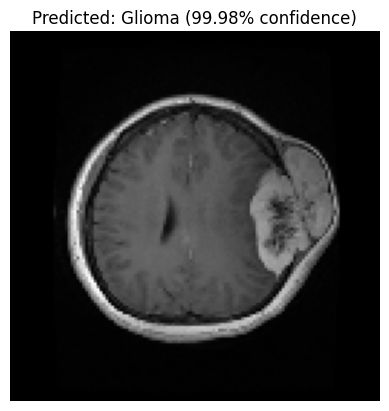

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


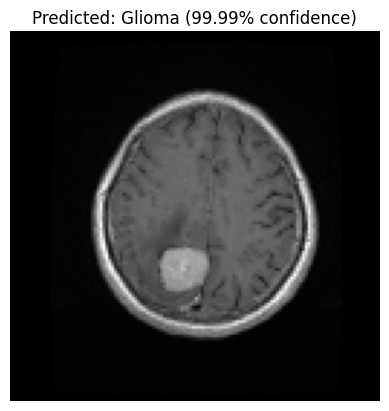

In [ ]:
# Upload your image
from google.colab import files
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Load your trained model (make sure it's in your Colab files)
model = load_model('brain_tumor_model.h5')  # or 'brain_tumor_model.keras' if you used the new format

# Define label map
label_map = {0: 'Glioma', 1: 'Pituitary Tumor', 2: 'Meningioma'}

for filename in uploaded.keys():
    # Load and preprocess image
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    img = img.reshape(1, 128, 128, 1).astype('float32') / 255.0

    # Make prediction
    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    # Show result
    plt.imshow(img.reshape(128, 128), cmap='gray')
    plt.title(f"Predicted: {label_map[class_index]} ({confidence*100:.2f}% confidence)")
    plt.axis('off')
    plt.show()
